## Loading KDEF dataset

This notebook has the necessary code to load and split your KDEF dataset. The training and test splits are already predefined.

In [1]:
EMOTIONS = {
    "AF": "afraid",
    "AN": "angry",
    "DI": "disgust",
    "HA": "happy",
    "NE": "neutral",
    "SA": "sad",
    "SU": "surprise"
}

POSES = {
    "FL": "full_left",
    "HL": "half_left",
    "S":  "straight",
    "HR": "half_right",
    "FR": "full_right",
}


In [2]:
# DATA HAD TO BE RENAMED, DEBUGGED TO CORRECTLY LOAD THE DATASET, SOME FILES WERE MALFORMED OR HAD WRONG NAMES
from pathlib import Path
import pandas as pd

ROOT = Path("data/kdef/KDEF/")

OVERRIDES = {
    "AF31V": "AF31SAHL",
    "AM31H": "AM31SUHR",
}

records = []

for img_path in ROOT.rglob("*.JPG"):
    stem = OVERRIDES.get(img_path.stem, img_path.stem)   # corrected name

    if len(stem) < 7:
        print("Skipping malformed:", img_path.stem)
        continue

    emotion_code = stem[4:6]
    pose_code = stem[6:]

    if emotion_code not in EMOTIONS or pose_code not in POSES:
        print("Skipping unknown:", img_path.stem)
        continue

    records.append({
        "path": str(img_path),          # original file path, unchanged
        "acquisition": stem[0],         # A or B
        "subject": stem[1:4],           # e.g. F31, M31
        "emotion": EMOTIONS[emotion_code],
        "pose": POSES[pose_code],
    })

df = pd.DataFrame(records)
print(len(df))
print(df["emotion"].value_counts())
print(df["pose"].value_counts())

4900
emotion
neutral     700
angry       700
afraid      700
happy       700
sad         700
disgust     700
surprise    700
Name: count, dtype: int64
pose
full_left     980
straight      980
half_right    980
half_left     980
full_right    980
Name: count, dtype: int64


In [3]:
df = pd.DataFrame(records)

print(df["emotion"].value_counts())
print()
print(df["subject"].nunique())
print(sorted(df.emotion.unique()))
print(df.pose.value_counts())


emotion
neutral     700
angry       700
afraid      700
happy       700
sad         700
disgust     700
surprise    700
Name: count, dtype: int64

70
['afraid', 'angry', 'disgust', 'happy', 'neutral', 'sad', 'surprise']
pose
full_left     980
straight      980
half_right    980
half_left     980
full_right    980
Name: count, dtype: int64


In [4]:
print(df)

                                  path acquisition subject  emotion  \
0     data/kdef/KDEF/AM03/AM03NEFL.JPG           A     M03  neutral   
1      data/kdef/KDEF/AM03/AM03ANS.JPG           A     M03    angry   
2     data/kdef/KDEF/AM03/AM03AFHR.JPG           A     M03   afraid   
3     data/kdef/KDEF/AM03/AM03HAHL.JPG           A     M03    happy   
4     data/kdef/KDEF/AM03/AM03NEHR.JPG           A     M03  neutral   
...                                ...         ...     ...      ...   
4895  data/kdef/KDEF/BM20/BM20DIFR.JPG           B     M20  disgust   
4896  data/kdef/KDEF/BM20/BM20SAHR.JPG           B     M20      sad   
4897  data/kdef/KDEF/BM20/BM20HAFR.JPG           B     M20    happy   
4898  data/kdef/KDEF/BM20/BM20NEFR.JPG           B     M20  neutral   
4899  data/kdef/KDEF/BM20/BM20NEHR.JPG           B     M20  neutral   

            pose  
0      full_left  
1       straight  
2     half_right  
3      half_left  
4     half_right  
...          ...  
4895  full_rig

In [6]:
import pickle

with open("auxFiles/kdef_subject_split.pkl", "rb") as f:
    split_data = pickle.load(f)

train_subjects = split_data["train_subjects"]
test_subjects = split_data["test_subjects"]

print(f"Train subjects: {len(train_subjects)}")
print(f"Test subjects : {len(test_subjects)}")


# Splitting the datasets between front facing images and for the train/test datasets
train_df = df[
    (df["subject"].isin(train_subjects))
    & (df["pose"] == "straight")
]

test_df = df[
    (df["subject"].isin(test_subjects))
    & (df["pose"] == "straight")
]

Train subjects: 56
Test subjects : 14


In [7]:
print("Train images:", len(train_df))
print("Test images :", len(test_df))

Train images: 784
Test images : 196


Subject: F35


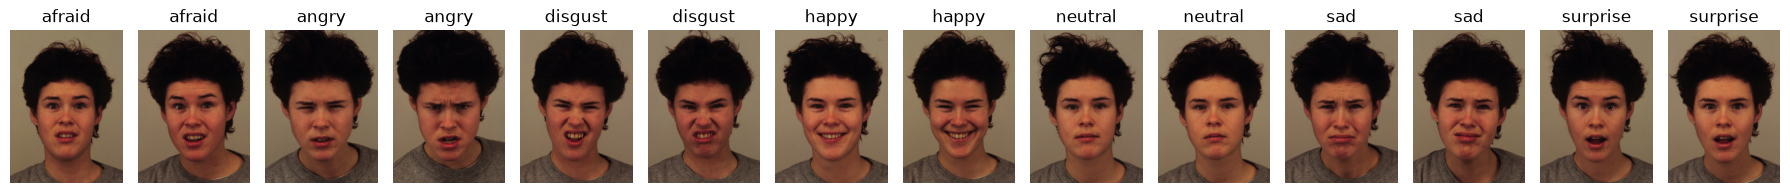

Subject: F11


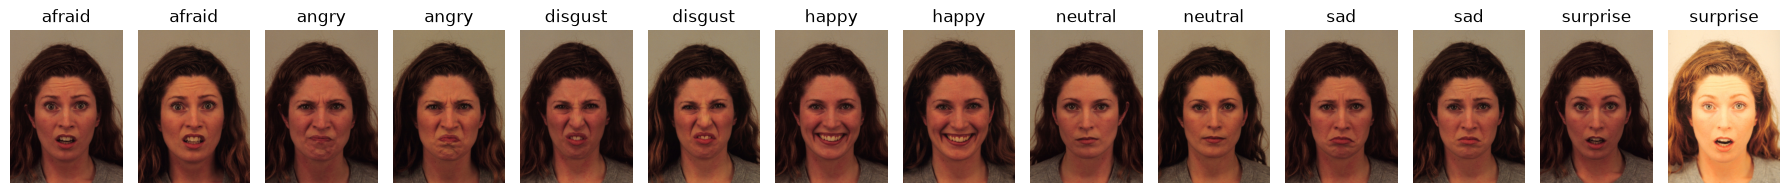

In [8]:
from src.utils_display import show_random_subject_emotions
show_random_subject_emotions(train_df)
show_random_subject_emotions(test_df)

The next part of the code iterates over all the images in the dataset and stores them in np arrays for easy processing

In [14]:
import cv2
from src.preprocess import preprocess_kdef_image
import numpy as np

X_train = []
y_train = []

for _, row in train_df.iterrows():

    try:
        img = preprocess_kdef_image(
            row["path"]
        )

        X_train.append(img)
        y_train.append(row["emotion"])

    except Exception as e:
        print(e)



X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = []
y_test = []

for _, row in test_df.iterrows():

    try:
        img = preprocess_kdef_image(
            row["path"]
        )

        X_test.append(img)
        y_test.append(row["emotion"])

    except Exception as e:
        print(e)

X_test = np.array(X_test)
y_test = np.array(y_test)


#Storing the preprocessed KDEF dataset


import pickle

data = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
}

with open("data/kdef/kdef_preprocessed.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved.")

Saved.


Now let's see a few of our preprocessed images. Note that both sessions A and B now are stored. The data array contains first all the A session images, and afterwards all the B session images

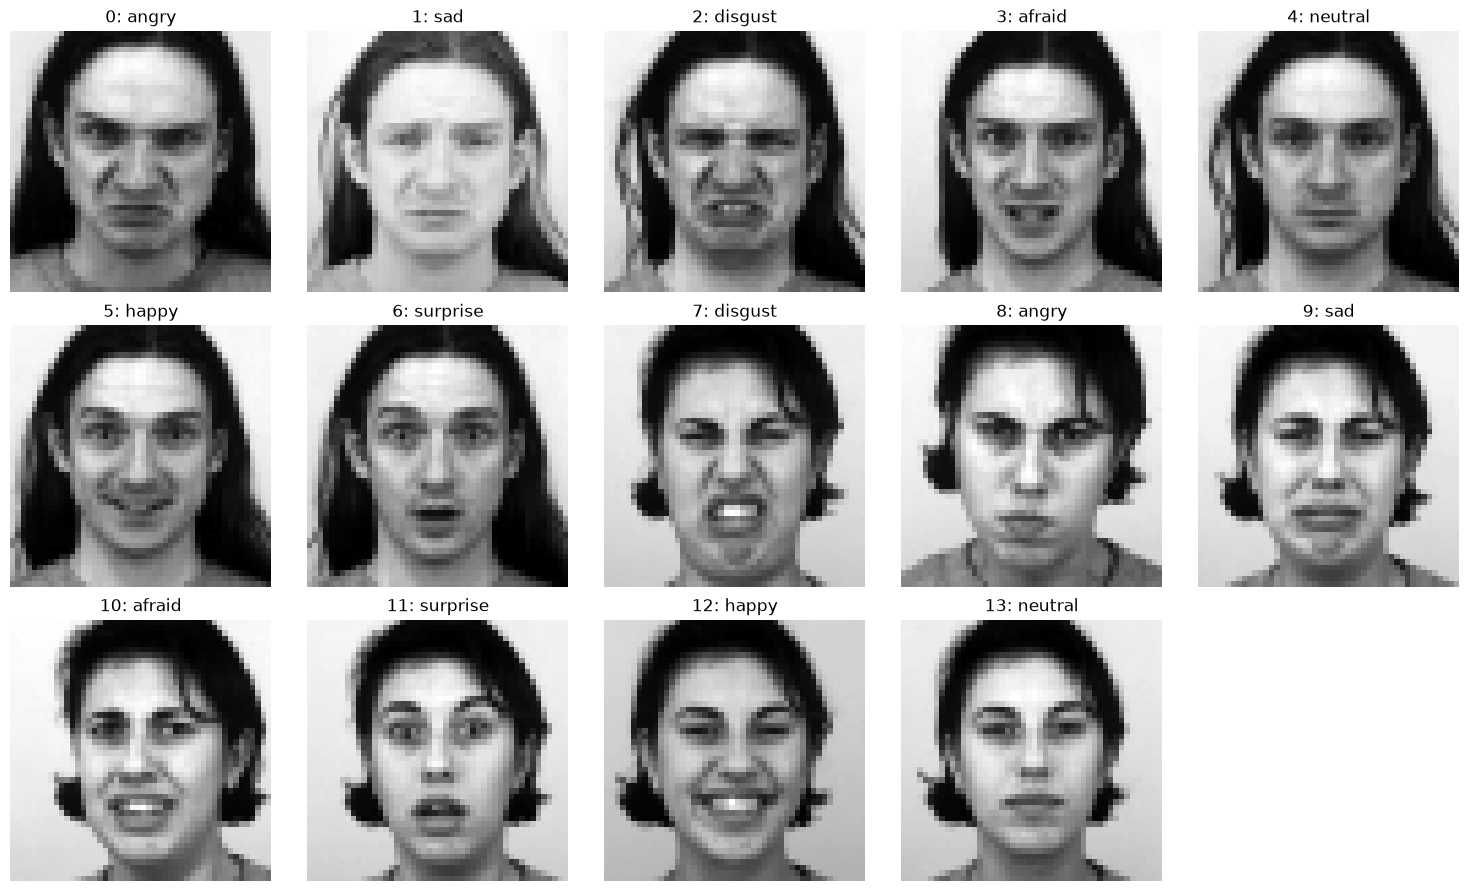

In [12]:
import matplotlib.pyplot as plt
import math


def show_samples(X, y, start_idx, end_idx):
    """
    Display images from start_idx to end_idx (exclusive)
    together with their emotion labels.
    """

    n = end_idx - start_idx
    cols = 5
    rows = math.ceil(n / cols)

    plt.figure(figsize=(3 * cols, 3 * rows))

    for i, idx in enumerate(range(start_idx, end_idx)):
        plt.subplot(rows, cols, i + 1)

        img = X[idx]

        # grayscale or RGB
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)

        plt.title(f"{idx}: {y[idx]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# This is an example of the images of the session A
show_samples(X_train, y_train, start_idx=0, end_idx=14)

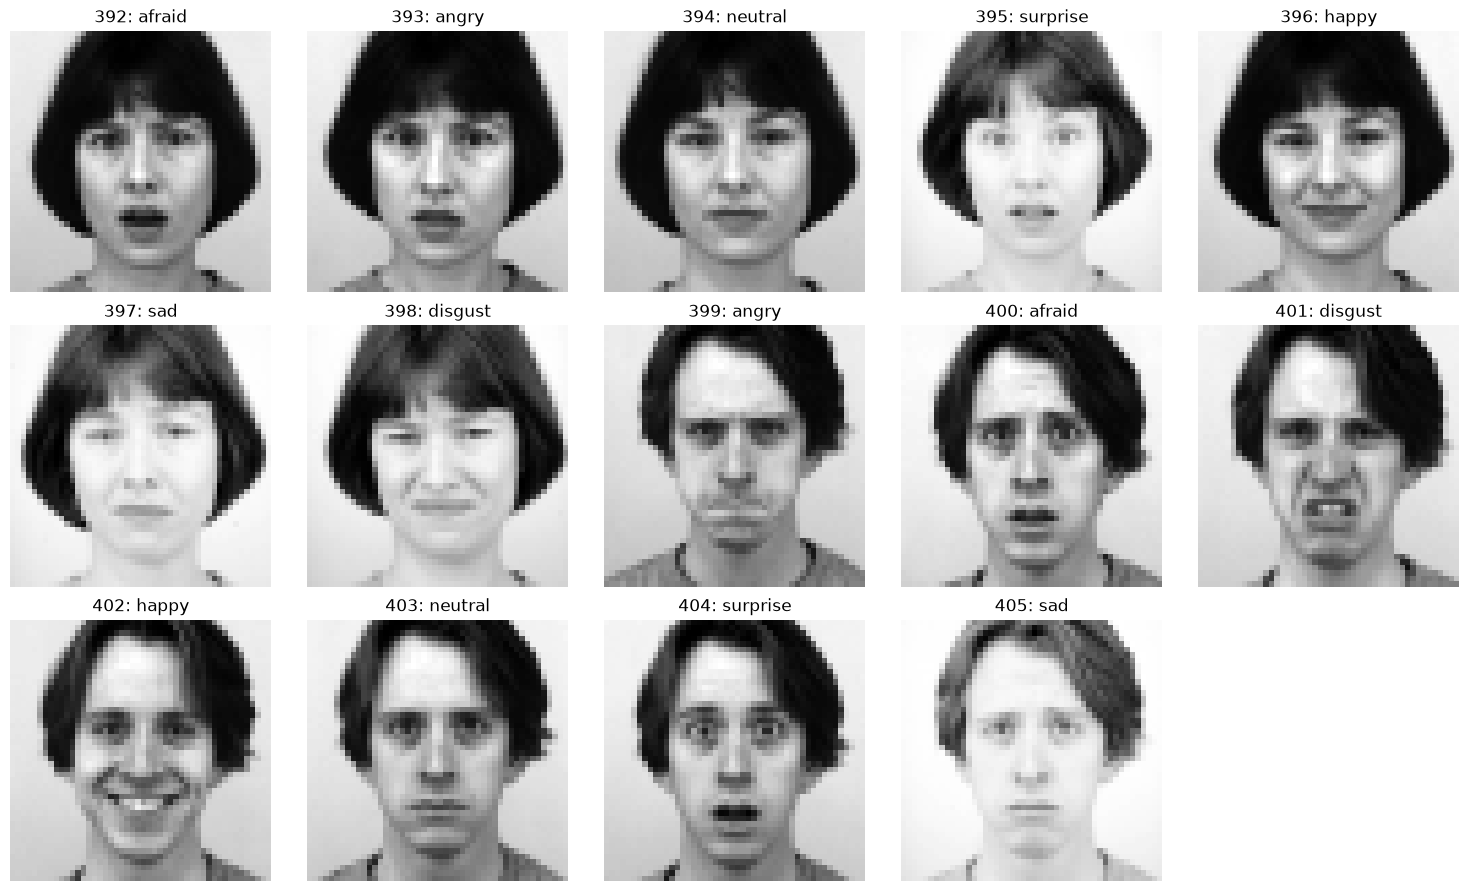

In [13]:
# This is an example of the images of the session B
show_samples(X_train, y_train, start_idx=392, end_idx=406)